# Metamorphosis solver -- test notebook

End-to-end walkthrough of every piece of the `src/` object model: image
loading, the individual building blocks of the exact solver (kernel,
velocity field, trajectory, warp, energy), both solvers (exact and
simplified) -- each stopping on convergence rather than a fixed iteration
count, with their loss curves plotted -- and the visualizer.

Pyramid scales below stop at half resolution so the notebook runs in
about a minute; the finest (native-resolution) level is far more
expensive per iteration -- a single run there took ~3 minutes in
testing. Extend `pyramid_scales` to `(..., 1.0)` for a production run.
The final section exports everything for the experiment run in this
notebook into `notebook_outputs/`.

In [21]:
import os
import sys
sys.path.insert(0, "src")

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage

%matplotlib inline

A0_PATH = "BDD_AMD_062026/031_FA_C_OD/preprocessed/UTF-8FAC20013.png"
A1_PATH = "BDD_AMD_062026/031_FA_C_OD/preprocessed/UTF-8FAC20023.png"

## 1. Load the input images

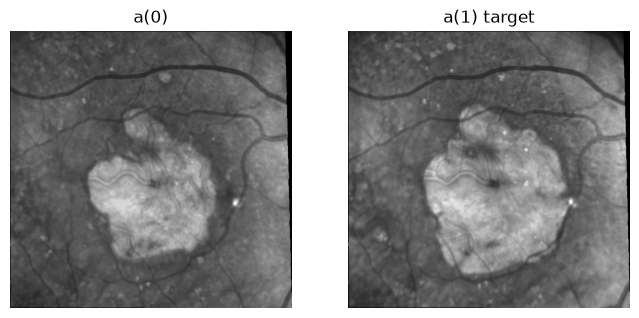

In [22]:
from Image import Image

img0 = Image(A0_PATH)
img1 = Image(A1_PATH)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img0.array, cmap="gray"); axes[0].set_title("a(0)"); axes[0].axis("off")
axes[1].imshow(img1.array, cmap="gray"); axes[1].set_title("a(1) target"); axes[1].axis("off")
plt.show()

## 2. Image preprocessing operators (`ImageOperators`)

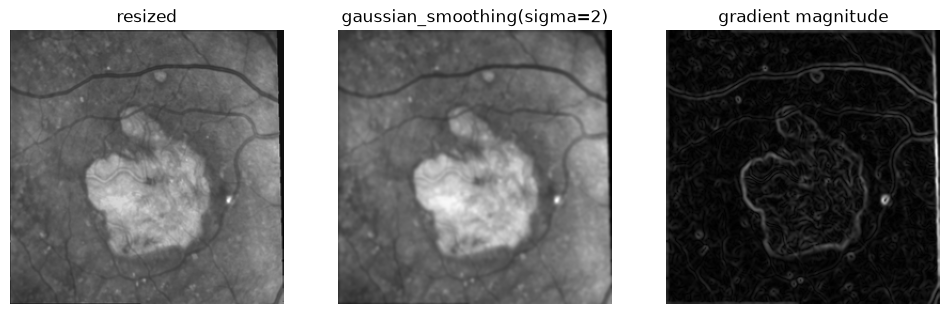

In [23]:
from Image import ImageOperators

resized = ImageOperators.resize(img0.array, (256, 256))
smoothed = ImageOperators.gaussian_smoothing(resized, sigma=1.0)
gx, gy = ImageOperators.gradient(smoothed)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(resized, cmap="gray"); axes[0].set_title("resized")
axes[1].imshow(smoothed, cmap="gray"); axes[1].set_title("gaussian_smoothing(sigma=2)")
axes[2].imshow(np.sqrt(gx**2 + gy**2), cmap="gray"); axes[2].set_title("gradient magnitude")
for ax in axes:
    ax.axis("off")
plt.show()

## 3. The building blocks of the exact solver (book section 13.4.3)

- `GaussianKernel` -- K and K^(1/2)
- `VelocityField` -- w(t) and v(t) = K^(1/2) w(t)
- `ImageTrajectory` -- free intermediate states a(1..T-1)
- `SemiLagrangianWarp` -- bilinear transport a(t+1, x + dt*v)
- `MetamorphosisEnergy` -- formula (13.13)

At zero-initialized w, v=0 and the trajectory is just the linear blend
between a(0) and a(1), so `E_data` below is the mismatch of a naive
linear interpolation -- the optimizer's job (next section) is to drive
it down.

In [24]:
from Pyramid import ResolutionPyramid
from Kernel import GaussianKernel
from VelocityField import VelocityField
from ImageTrajectory import ImageTrajectory
from Warp import SemiLagrangianWarp
from Energy import MetamorphosisEnergy

a0_t = torch.tensor(img0.array, dtype=torch.float32)
a1_t = torch.tensor(img1.array, dtype=torch.float32)

h, w = 64, 64
a0_small = ResolutionPyramid.resize_image(a0_t, (h, w))
a1_small = ResolutionPyramid.resize_image(a1_t, (h, w))

T_demo = 5
kernel = GaussianKernel.at_scale_fraction(0.05, h, w)
velocity = VelocityField.zeros(T_demo, h, w, kernel)                  # w(t) = 0 -> v(t) = 0
trajectory = ImageTrajectory.linear_init(a0_small, a1_small, T_demo)  # a(1..T-1) = linear blend
warp = SemiLagrangianWarp(h, w)
energy_fn = MetamorphosisEnergy(dt=1.0 / T_demo, lambda_data=20.0)

loss, e_kinetic, e_data = energy_fn.compute(velocity, trajectory, warp)
print(f"kernel sigma={kernel.sigma:.2f}")
print(f"loss={loss.item():.3f}  E_kinetic={e_kinetic.item():.3f}  E_data={e_data.item():.5f}")

kernel sigma=3.20
loss=883.925  E_kinetic=0.000  E_data=1.76785


## 4. Running `MetamorphosisSolver` directly (low-level)

Same objects as above, now driven through the full multi-resolution
optimization loop. `level_iters` is just a *cap* per level: each level
stops as soon as the loss hasn't improved by `convergence_tol` (relative)
for `convergence_patience` iterations -- see `src/Convergence.py`. A
`convergence_min_iters` warmup keeps the zero-deformation start (which
has zero kinetic cost) from looking like a false early optimum.


--- Level 1/2 (72x74, sigma_K=2.22, lr=0.02, max 200 iters) ---
  iter    0  loss=   1441.9882  E_kin=    0.0000  E_data=    2.002761  rms=0.00792 (~2.02/255)
  iter  100  loss=   1417.6008  E_kin=   23.3268  E_data=    1.936492  rms=0.00778 (~1.98/255)
  converged at iter 130 (no improvement for 20 iters)  rms=0.00778 (~1.98/255)

--- Level 2/2 (144x147, sigma_K=4.41, lr=0.01, max 200 iters) ---
  iter    0  loss=  16906.2051  E_kin=   89.1507  E_data=   23.357021  rms=0.01356 (~3.46/255)
  iter  100  loss=   6787.8091  E_kin=   33.8581  E_data=    9.380487  rms=0.00859 (~2.19/255)
  converged at iter 114 (no improvement for 20 iters)  rms=0.00859 (~2.19/255)

final loss: 6787.57958984375


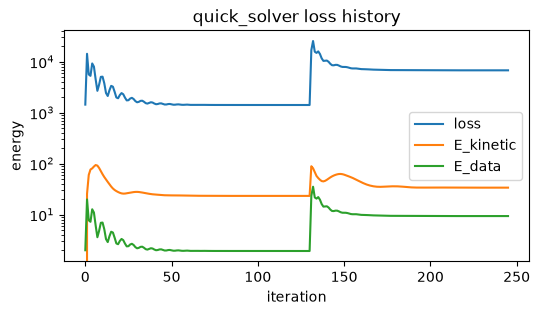

In [25]:
from Solver import MetamorphosisSolver

quick_solver = MetamorphosisSolver(
    T=6, kernel_sigma_frac=0.03,
    pyramid_scales=(1 / 8, 1 / 4),
    level_iters=(200, 200),               # caps -- convergence will likely stop earlier
    level_lrs=(0.02, 0.01),
    convergence_tol=1e-4, convergence_patience=20, convergence_min_iters=20,
)
velocity, trajectory, warp = quick_solver.fit(a0_t, a1_t)
print("\nfinal loss:", quick_solver.history[-1][1])

hist = np.array(quick_solver.history)
plt.figure(figsize=(6, 3))
for col, label in zip(hist[:, 1:].T, ["loss", "E_kinetic", "E_data"]):
    plt.plot(col, label=label)
plt.yscale("log"); plt.xlabel("iteration"); plt.ylabel("energy")
plt.legend(); plt.title("quick_solver loss history")
plt.show()

## 5. The `Metamorphosis` facade (recommended entry point)

Wraps loading + solving + reconstruction of v(t)/z(t) into one call, and
keeps the solver's loss history (`metamorphosis.history`). This is the
object `MetamorphosisVisualizer` and `.save()` / `.load()` expect.

In [26]:
from Metamorphosis import Metamorphosis

metamorphosis = Metamorphosis.fit(
    A0_PATH, A1_PATH,
    T=8, lambda_data=2000.0, kernel_sigma_frac=0.03,
    pyramid_scales=(1 / 8, 1 / 4, 1 / 2),
    level_iters=(400, 400, 400),          # raised from 300 -- 2000 needs more room to settle
    level_lrs=(0.02, 0.01, 0.008),
    convergence_tol=1e-4, convergence_patience=25, convergence_min_iters=25,
)

print(metamorphosis.a_traj.shape, metamorphosis.v_traj_x.shape, metamorphosis.z_traj.shape)


--- Level 1/3 (72x74, sigma_K=2.22, lr=0.02, max 400 iters) ---
  iter    0  loss= 192265.1406  E_kin=    0.0000  E_data=    1.502071  rms=0.00594 (~1.51/255)
  iter  100  loss= 108197.7188  E_kin=19731.9980  E_data=    0.691138  rms=0.00403 (~1.03/255)
  iter  200  loss=  97424.4609  E_kin=29200.2246  E_data=    0.533002  rms=0.00354 (~0.90/255)
  iter  300  loss=  95916.3828  E_kin=31393.2188  E_data=    0.504087  rms=0.00344 (~0.88/255)
  iter  399  loss=  95614.8516  E_kin=32063.8496  E_data=    0.496492  rms=0.00341 (~0.87/255)

--- Level 2/3 (144x147, sigma_K=4.41, lr=0.01, max 400 iters) ---
  iter    0  loss=2532999.5000  E_kin=121042.6875  E_data=   18.843412  rms=0.01055 (~2.69/255)
  iter  100  loss= 682910.8125  E_kin=150583.3750  E_data=    4.158808  rms=0.00496 (~1.26/255)
  iter  200  loss= 681075.2500  E_kin=158569.2500  E_data=    4.082078  rms=0.00491 (~1.25/255)
  converged at iter 242 (no improvement for 25 iters)  rms=0.00490 (~1.25/255)

--- Level 3/3 (289x294, s

## 6. The simplified (shooting) solver, for comparison

Approximate scheme: explicit residual z(t), Eulerian transport, v = K w.
Kept separate from the exact scheme since it isn't book-faithful (see
`src/SimplifiedSolver.py`'s docstring for the precise differences). Same
convergence-based stopping applies here.


--- Level 1/3 (72x74, sigma_K=2.22, lr=0.05, max 300 iters) ---
  iter    0  loss=  24033.1230  E_v=    0.0000  E_z=    0.0000  data_term=  12.01656  rms=0.04749 (~12.11/255)
  iter  100  loss=    234.2444  E_v=    3.5456  E_z=   11.4026  data_term=   0.00132  rms=0.00050 (~0.13/255)
  iter  200  loss=    232.9837  E_v=    3.9776  E_z=   11.3372  data_term=   0.00113  rms=0.00046 (~0.12/255)
  iter  299  loss=    232.6071  E_v=    4.3416  E_z=   11.3006  data_term=   0.00113  rms=0.00046 (~0.12/255)

--- Level 2/3 (144x147, sigma_K=4.41, lr=0.03, max 300 iters) ---
  iter    0  loss=  12654.1777  E_v=   16.6046  E_z=   39.6117  data_term=   5.92267  rms=0.01673 (~4.27/255)
  iter  100  loss=   1117.3325  E_v=    7.7583  E_z=   54.9063  data_term=   0.00572  rms=0.00052 (~0.13/255)
  converged at iter 152 (no improvement for 20 iters)  rms=0.00051 (~0.13/255)

--- Level 3/3 (289x294, sigma_K=8.82, lr=0.02, max 300 iters) ---
  iter    0  loss=  23620.0977  E_v=   31.5278  E_z=  204.017

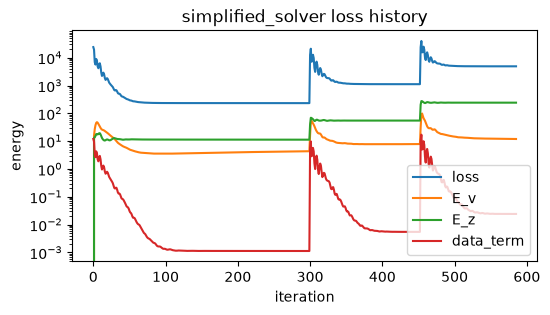

In [27]:
from SimplifiedSolver import SimplifiedMetamorphosisSolver

simplified_solver = SimplifiedMetamorphosisSolver(
    T=8, sigma2=0.05, lambda_data=2000.0, kernel_sigma_frac=0.03,
    pyramid_scales=(1 / 8, 1 / 4, 1 / 2),
    level_iters=(300, 300, 300),
    level_lrs=(0.05, 0.03, 0.02),
    convergence_tol=1e-4, convergence_patience=20, convergence_min_iters=20,
)
simplified_solver.fit(a0_t, a1_t)
print("final data_term:", simplified_solver.history[-1][-1])

hist = np.array(simplified_solver.history)
plt.figure(figsize=(6, 3))
for col, label in zip(hist[:, 1:].T, ["loss", "E_v", "E_z", "data_term"]):
    plt.plot(col, label=label)
plt.yscale("log"); plt.xlabel("iteration"); plt.ylabel("energy")
plt.legend(); plt.title("simplified_solver loss history")
plt.show()

## 7. Visualizing results

The central diagnostic is the v-vs-z separation: deformation should
explain geometric change, the residual should explain pure intensity
change (see `Metamorphosis.deformation_magnitude()` / `.residual_magnitude()`).
These plots are written straight into `notebook_outputs/`, the export
folder for this experiment.

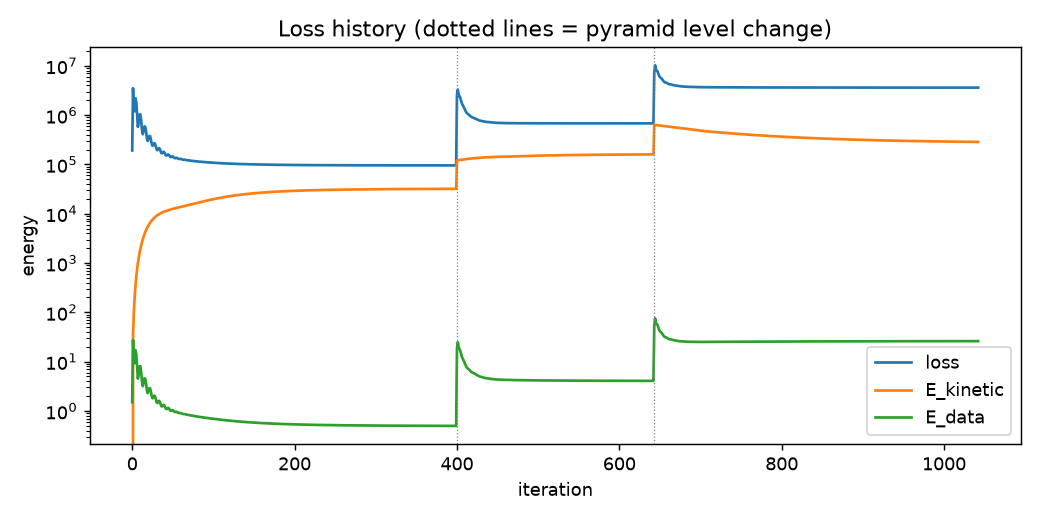

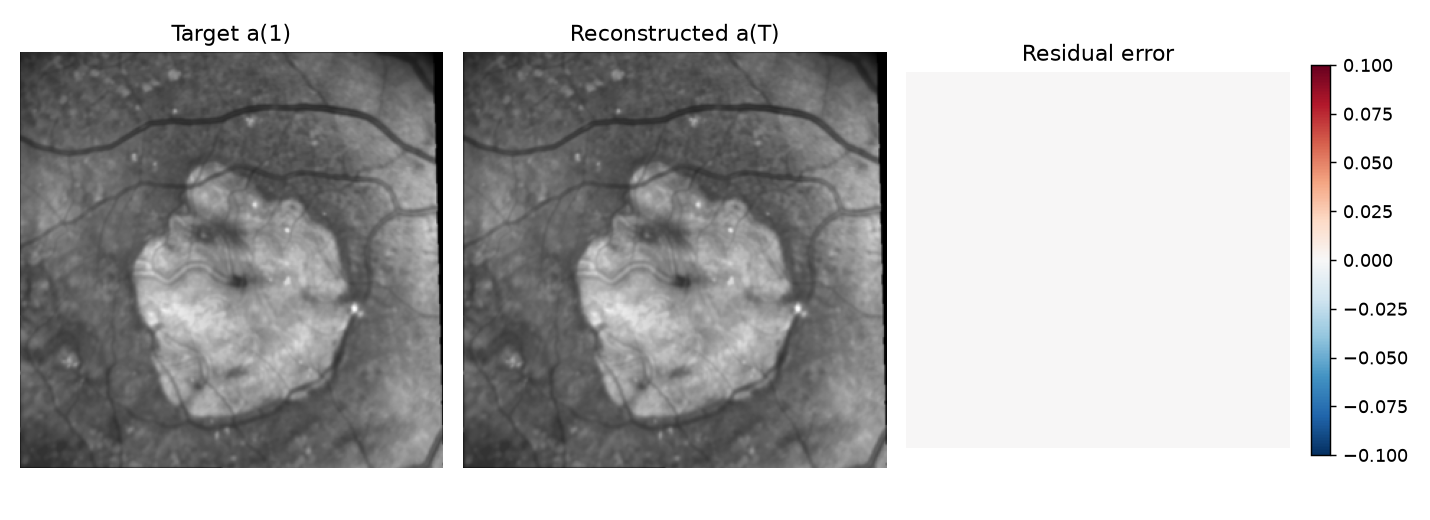

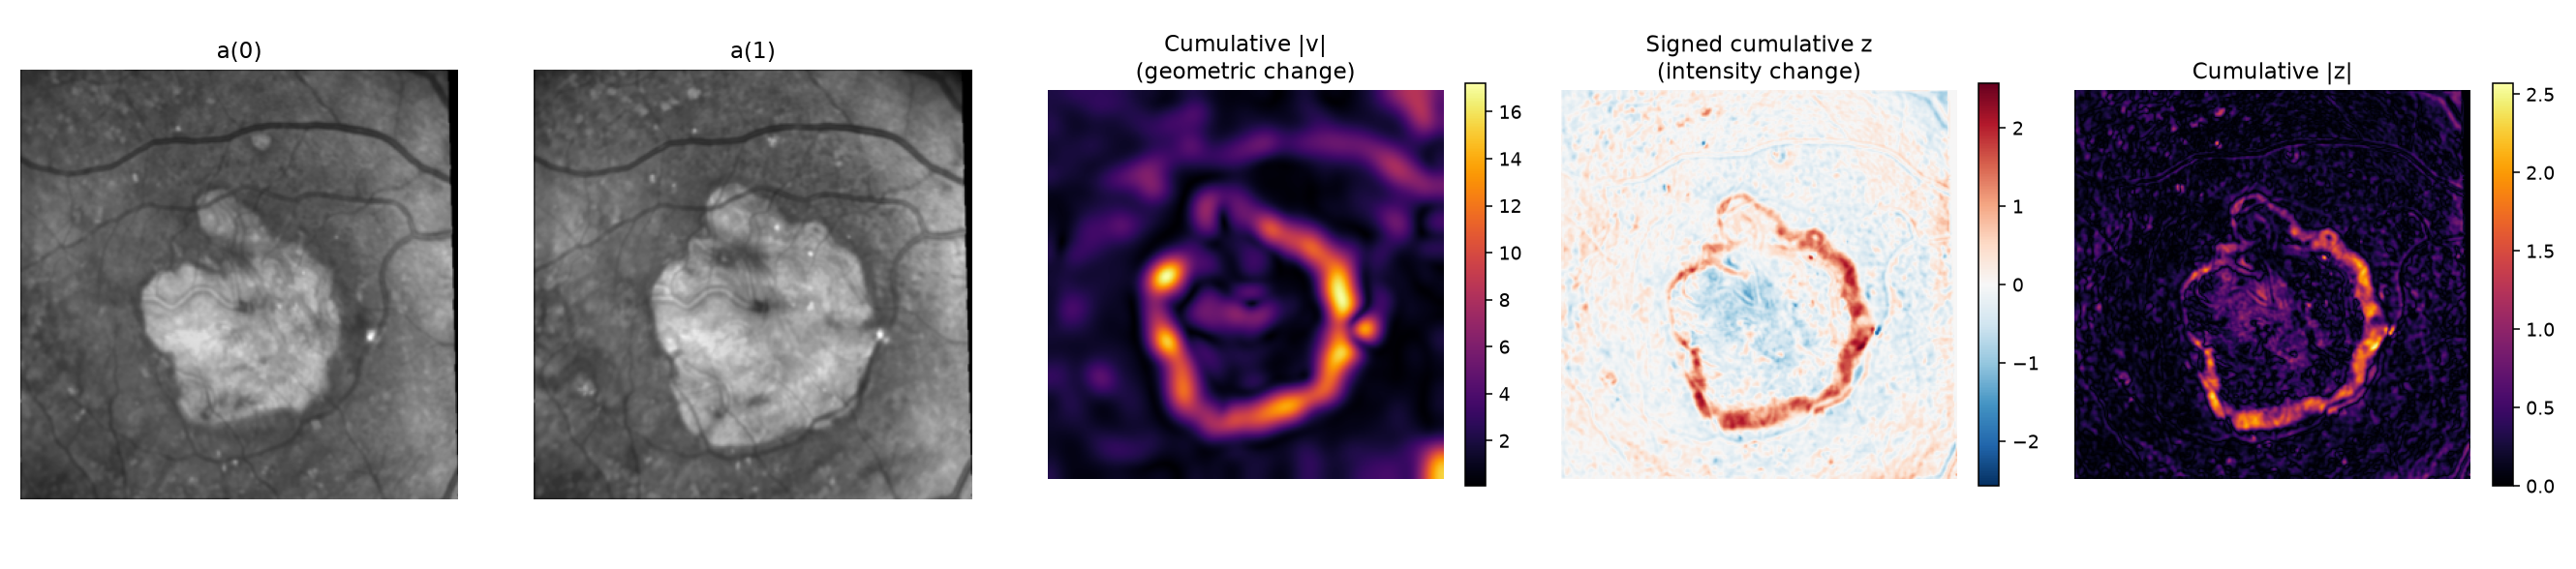

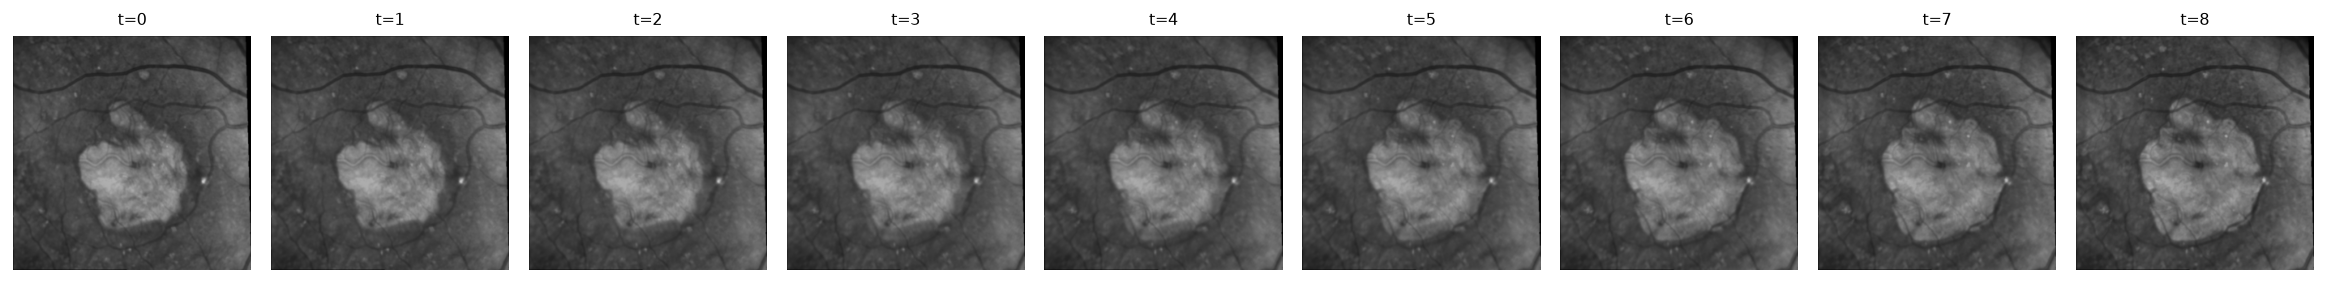

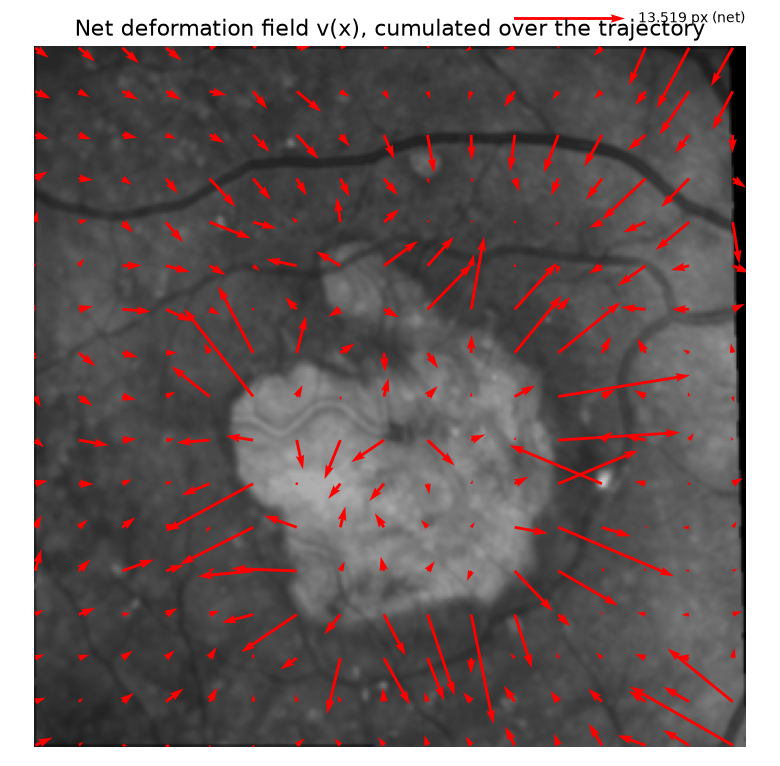

In [28]:
from Visualizer import MetamorphosisVisualizer

os.makedirs("notebook_outputs", exist_ok=True)
viz = MetamorphosisVisualizer(metamorphosis)

viz.plot_loss_history(metamorphosis.history, "notebook_outputs/fig_loss.png")
display(IPImage("notebook_outputs/fig_loss.png"))

viz.plot_matching("notebook_outputs/fig_matching.png")
display(IPImage("notebook_outputs/fig_matching.png"))

viz.plot_deformation_vs_residual("notebook_outputs/fig_v_vs_z.png")
display(IPImage("notebook_outputs/fig_v_vs_z.png"))

viz.plot_trajectory_strip("notebook_outputs/fig_trajectory.png")
display(IPImage("notebook_outputs/fig_trajectory.png"))

viz.plot_vector_field("notebook_outputs/fig_vector_field.png")
display(IPImage("notebook_outputs/fig_vector_field.png"))


## 8. Saving / exporting the experiment

Writes `a_traj` / `v_traj_x` / `v_traj_y` / `z_traj` / `a0` / `a1` /
`history` (loadable later via `Metamorphosis.load(...)`), plus every
figure and frame sequence (trajectory, deformation grid, residual,
velocity, loss) for this run into `notebook_outputs/`.

In [29]:
metamorphosis.save("notebook_outputs")
viz.export_all("notebook_outputs")
print("Saved trajectory/velocity/residual/history arrays and all figures to notebook_outputs/")

Saved trajectory/velocity/residual/history arrays and all figures to notebook_outputs/
